In [2]:
from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Generalizable-DDA-RL

Mounted at /content/drive
/content/drive/MyDrive/Generalizable-DDA-RL


In [4]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Generalizable-DDA-RL" in root:
        print(root)

/content/drive/MyDrive/Generalizable-DDA-RL
/content/drive/MyDrive/Generalizable-DDA-RL/src
/content/drive/MyDrive/Generalizable-DDA-RL/src/__pycache__
/content/drive/MyDrive/Generalizable-DDA-RL/notebooks
/content/drive/MyDrive/Generalizable-DDA-RL/configs
/content/drive/MyDrive/Generalizable-DDA-RL/models
/content/drive/MyDrive/Generalizable-DDA-RL/results
/content/drive/MyDrive/Generalizable-DDA-RL/results/figures
/content/drive/MyDrive/Generalizable-DDA-RL/results/tables
/content/drive/MyDrive/Generalizable-DDA-RL/results/trajectories
/content/drive/MyDrive/Generalizable-DDA-RL/results/training
/content/drive/MyDrive/Generalizable-DDA-RL/results/generalization
/content/drive/MyDrive/Generalizable-DDA-RL/results/generalization/figures
/content/drive/MyDrive/Generalizable-DDA-RL/results/generalization/trajectories
/content/drive/MyDrive/Generalizable-DDA-RL/results/generalization/tables
/content/drive/MyDrive/Generalizable-DDA-RL/results/ablation
/content/drive/MyDrive/Generalizable-

In [5]:
PROJECT_PATH = "/content/drive/MyDrive/Generalizable-DDA-RL"

print("Project exists:", os.path.exists(PROJECT_PATH))
print("Project path:", PROJECT_PATH)

Project exists: True
Project path: /content/drive/MyDrive/Generalizable-DDA-RL


### ***Move into Project Directory***

In [7]:
import os
import sys

os.chdir(PROJECT_PATH)

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

print("Current directory:")
print(os.getcwd())

print("\nProject contents:")
print(os.listdir(PROJECT_PATH))

Current directory:
/content/drive/MyDrive/Generalizable-DDA-RL

Project contents:
['src', 'notebooks', 'configs', 'models', 'results', 'docs', 'paper', 'figures']


In [8]:
!pip install -q stable-baselines3 gymnasium scipy pandas numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.5 MB/s eta 0:00:00


### ***Imports***

In [9]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, t

from stable_baselines3 import PPO

from src.environment import GADDAEnv

print("Imports Successful")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Imports Successful


In [10]:
MODEL_PATH = "models/ppo_dda.zip"

print("Model exists:", os.path.exists(MODEL_PATH))

ppo_model = PPO.load(
    MODEL_PATH,
    device="cpu"
)

print("Model Loaded :)")

Model exists: True
Model Loaded :)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Robustness Testing Setup***

In [11]:
ROBUSTNESS_NOISE_LEVELS = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.30
]

ROBUSTNESS_SEEDS = list(range(100, 110))

TARGET_WIN_RATE = 0.70
MAX_STEPS = 200

print("Noise levels:", ROBUSTNESS_NOISE_LEVELS)
print("Seeds:", ROBUSTNESS_SEEDS)
print("Total evaluation runs:",
      len(ROBUSTNESS_NOISE_LEVELS) * len(ROBUSTNESS_SEEDS))

Noise levels: [0.05, 0.1, 0.15, 0.2, 0.3]
Seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
Total evaluation runs: 50


### ***Behavioural Robustness Evaluation***
We'll use a controlled player profile and vary only its noise_std.

To make this a clean experiment, we'll use the same central player configuration:

initial_skill = 0.50
learning_rate = 0.0
fatigue_rate = 0.0

and vary :
noise_std

In [18]:
# Cell 8 — Behavioural Noise Robustness Evaluation

results = []

BASE_PLAYER_CONFIG = {
    "initial_skill": 0.50,
    "learning_rate": 0.0,
    "fatigue_rate": 0.0
}

for noise in ROBUSTNESS_NOISE_LEVELS:
    print(f"Testing noise_std = {noise}")

    for seed in ROBUSTNESS_SEEDS:

        player_config = BASE_PLAYER_CONFIG.copy()
        player_config["noise_std"] = noise

        env = GADDAEnv(
            max_steps=MAX_STEPS,
            target_win_rate=TARGET_WIN_RATE,
            player_config=player_config,
            seed=seed
        )

        obs, info = env.reset(seed=seed)

        total_reward = 0.0
        trajectory = []

        for step in range(MAX_STEPS):

            action, _ = ppo_model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            trajectory.append({
                "Difficulty": info["difficulty"],
                "Recent Win Rate": info["recent_win_rate"],
                "Estimated Skill": info["estimated_skill"],
                "Uncertainty": info["uncertainty"],
                "Reward": reward
            })

            if terminated or truncated:
                break

        trajectory_df = pd.DataFrame(trajectory)

        mean_win_rate = trajectory_df["Recent Win Rate"].mean()
        final_win_rate = trajectory_df["Recent Win Rate"].iloc[-1]

        results.append({
            "Noise Level": noise,
            "Seed": seed,
            "Total Reward": total_reward,
            "Final Rolling Win Rate": final_win_rate,
            "Mean Win Rate": mean_win_rate,
            "Win Rate Error": abs(mean_win_rate - TARGET_WIN_RATE),
            "Difficulty Std": trajectory_df["Difficulty"].std(),
            "Mean Absolute Difficulty Change": (
                trajectory_df["Difficulty"].diff().abs().mean()
            ),
            "Episode Length": len(trajectory_df)
        })

        env.close()

robustness_df = pd.DataFrame(results)

print("\nRobustness evaluation complete.")
print(f"Total runs: {len(robustness_df)}")

Testing noise_std = 0.05
Testing noise_std = 0.1
Testing noise_std = 0.15
Testing noise_std = 0.2
Testing noise_std = 0.3

Robustness evaluation complete.
Total runs: 50


In [19]:
robustness_df.head()

,Noise Level,Seed,Total Reward,Final Rolling Win Rate,Mean Win Rate,Win Rate Error,Difficulty Std,Mean Absolute Difficulty Change,Episode Length
0,0.05,100,220.803608,0.7,0.712960,0.012960,0.100332,0.056053,200
1,0.05,101,209.801915,0.6,0.728675,0.028675,0.120282,0.059046,200
2,0.05,102,225.101020,0.7,0.730925,0.030925,0.100265,0.057982,200
3,0.05,103,216.238292,0.7,0.726732,0.026732,0.118776,0.055049,200
4,0.05,104,214.645487,0.8,0.728105,0.028105,0.108829,0.053403,200


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
robustness_df.shape

(50, 9)

In [21]:
robustness_df["Noise Level"].value_counts().sort_index()

,count
Noise Level,
0.05,10
0.10,10
0.15,10
0.20,10
0.30,10


### ***Robustness Summary***

In [22]:
robustness_summary = (
    robustness_df
    .groupby("Noise Level")
    .agg(
        Win_Rate_Error_Mean=("Win Rate Error", "mean"),
        Win_Rate_Error_Std=("Win Rate Error", "std"),
        Total_Reward_Mean=("Total Reward", "mean"),
        Total_Reward_Std=("Total Reward", "std"),
        Final_Win_Rate_Mean=("Final Rolling Win Rate", "mean"),
        Final_Win_Rate_Std=("Final Rolling Win Rate", "std"),
        Difficulty_Std_Mean=("Difficulty Std", "mean"),
        Mean_Abs_Difficulty_Change=("Mean Absolute Difficulty Change", "mean")
    )
    .reset_index()
)

robustness_summary

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Noise Level,Win_Rate_Error_Mean,Win_Rate_Error_Std,Total_Reward_Mean,Total_Reward_Std,Final_Win_Rate_Mean,Final_Win_Rate_Std,Difficulty_Std_Mean,Mean_Abs_Difficulty_Change
0,0.05,0.025627,0.007692,216.840026,6.913884,0.74,0.069921,0.113231,0.057516
1,0.10,0.021586,0.011715,210.370561,7.790887,0.73,0.082327,0.117805,0.056567
2,0.15,0.021392,0.010589,212.348299,8.493575,0.75,0.070711,0.113090,0.054639
3,0.20,0.017781,0.009510,209.536625,8.386535,0.72,0.078881,0.117419,0.054783
4,0.30,0.010726,0.005261,204.716021,11.275369,0.72,0.091894,0.122903,0.053013


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
robustness_summary.round(4)

,Noise Level,Win_Rate_Error_Mean,Win_Rate_Error_Std,Total_Reward_Mean,Total_Reward_Std,Final_Win_Rate_Mean,Final_Win_Rate_Std,Difficulty_Std_Mean,Mean_Abs_Difficulty_Change
0,0.05,0.0256,0.0077,216.8400,6.9139,0.74,0.0699,0.1132,0.0575
1,0.10,0.0216,0.0117,210.3706,7.7909,0.73,0.0823,0.1178,0.0566
2,0.15,0.0214,0.0106,212.3483,8.4936,0.75,0.0707,0.1131,0.0546
3,0.20,0.0178,0.0095,209.5366,8.3865,0.72,0.0789,0.1174,0.0548
4,0.30,0.0107,0.0053,204.7160,11.2754,0.72,0.0919,0.1229,0.0530


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Save Raw and Summary Results***

In [24]:
import os

RESULTS_DIR = "results/robustness"
FIGURES_DIR = "figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

robustness_df.to_csv(
    f"{RESULTS_DIR}/behavioural_noise_robustness_raw_results.csv",
    index=False
)

robustness_summary.to_csv(
    f"{RESULTS_DIR}/behavioural_noise_robustness_summary.csv",
    index=False
)

print("Saved:")
print(f"- {RESULTS_DIR}/behavioural_noise_robustness_raw_results.csv")
print(f"- {RESULTS_DIR}/behavioural_noise_robustness_summary.csv")

Saved:
- results/robustness/behavioural_noise_robustness_raw_results.csv
- results/robustness/behavioural_noise_robustness_summary.csv


### ***Plot Win Rate Error and Behavioural Noise***

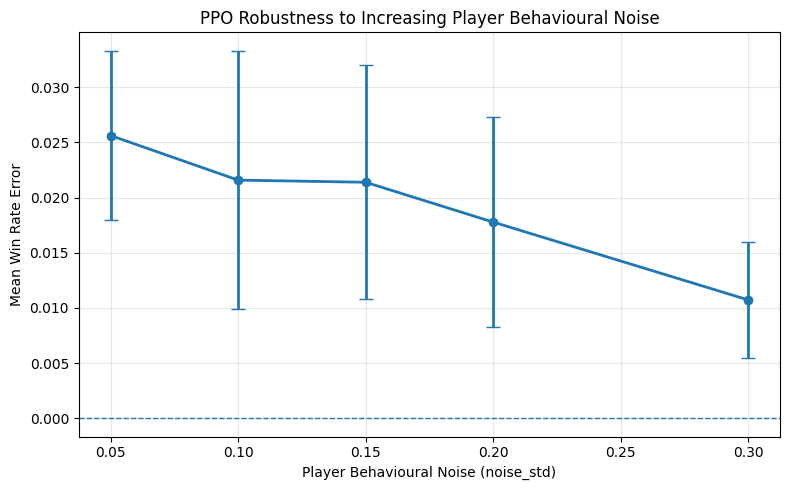

In [25]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    robustness_summary["Noise Level"],
    robustness_summary["Win_Rate_Error_Mean"],
    yerr=robustness_summary["Win_Rate_Error_Std"],
    marker="o",
    capsize=5,
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Player Behavioural Noise (noise_std)")
plt.ylabel("Mean Win Rate Error")
plt.title("PPO Robustness to Increasing Player Behavioural Noise")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_DIR}/behavioural_noise_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Plot Total Reward vs Noise***

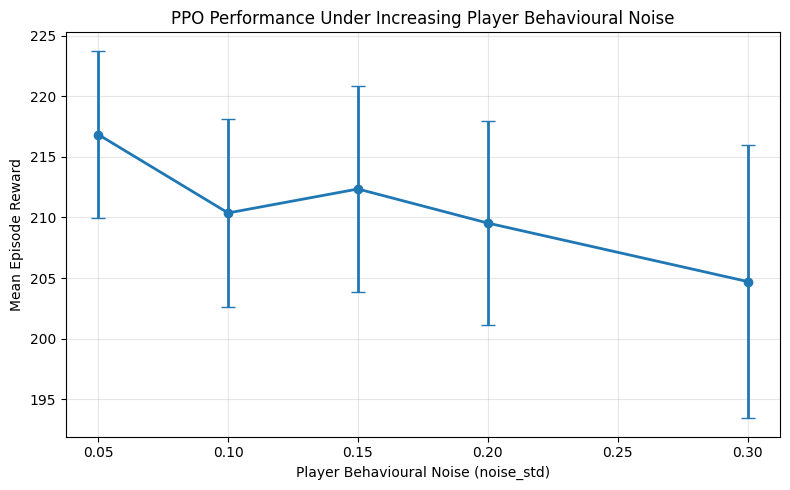

In [26]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    robustness_summary["Noise Level"],
    robustness_summary["Total_Reward_Mean"],
    yerr=robustness_summary["Total_Reward_Std"],
    marker="o",
    capsize=5,
    linewidth=2
)

plt.xlabel("Player Behavioural Noise (noise_std)")
plt.ylabel("Mean Episode Reward")
plt.title("PPO Performance Under Increasing Player Behavioural Noise")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_DIR}/behavioural_noise_reward.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Basic Robustness Interpretation Table***

In [27]:
robustness_summary[
    [
        "Noise Level",
        "Win_Rate_Error_Mean",
        "Win_Rate_Error_Std",
        "Total_Reward_Mean",
        "Final_Win_Rate_Mean"
    ]
].round(4)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Noise Level,Win_Rate_Error_Mean,Win_Rate_Error_Std,Total_Reward_Mean,Final_Win_Rate_Mean
0,0.05,0.0256,0.0077,216.8400,0.74
1,0.10,0.0216,0.0117,210.3706,0.73
2,0.15,0.0214,0.0106,212.3483,0.75
3,0.20,0.0178,0.0095,209.5366,0.72
4,0.30,0.0107,0.0053,204.7160,0.72


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Clean Robust Output***

In [28]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(
    robustness_summary[
        [
            "Noise Level",
            "Win_Rate_Error_Mean",
            "Win_Rate_Error_Std",
            "Total_Reward_Mean",
            "Total_Reward_Std",
            "Final_Win_Rate_Mean",
            "Final_Win_Rate_Std"
        ]
    ].round(4).to_string(index=False)
)

 Noise Level  Win_Rate_Error_Mean  Win_Rate_Error_Std  Total_Reward_Mean  Total_Reward_Std  Final_Win_Rate_Mean  Final_Win_Rate_Std
        0.05               0.0256              0.0077           216.8400            6.9139                 0.74              0.0699
        0.10               0.0216              0.0117           210.3706            7.7909                 0.73              0.0823
        0.15               0.0214              0.0106           212.3483            8.4936                 0.75              0.0707
        0.20               0.0178              0.0095           209.5366            8.3865                 0.72              0.0789
        0.30               0.0107              0.0053           204.7160           11.2754                 0.72              0.0919


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Verify Actual Noise Levels***

In [29]:
print("Noise levels:", sorted(robustness_df["Noise Level"].unique()))
print("Number of runs:", len(robustness_df))

Noise levels: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3)]
Number of runs: 50


### ***Check Raw Data Directly***

In [30]:
robustness_df[
    [
        "Noise Level",
        "Seed",
        "Win Rate Error",
        "Total Reward",
        "Final Rolling Win Rate"
    ]
].head(15)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Noise Level,Seed,Win Rate Error,Total Reward,Final Rolling Win Rate
0,0.05,100,0.012960,220.803608,0.7
1,0.05,101,0.028675,209.801915,0.6
2,0.05,102,0.030925,225.101020,0.7
3,0.05,103,0.026732,216.238292,0.7
4,0.05,104,0.028105,214.645487,0.8
5,0.05,105,0.017675,222.980819,0.8
6,0.05,106,0.032264,226.034988,0.7
7,0.05,107,0.035841,204.959242,0.8
8,0.05,108,0.027966,216.268660,0.8
9,0.05,109,0.015127,211.566233,0.8


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Trend Analysis***

In [31]:
from scipy.stats import spearmanr, pearsonr

noise = robustness_summary["Noise Level"]

error = robustness_summary["Win_Rate_Error_Mean"]
reward = robustness_summary["Total_Reward_Mean"]

spearman_error = spearmanr(noise, error)
spearman_reward = spearmanr(noise, reward)

pearson_error = pearsonr(noise, error)
pearson_reward = pearsonr(noise, reward)

print("Spearman correlation: Noise vs Win Rate Error")
print(f"rho = {spearman_error.statistic:.4f}, p = {spearman_error.pvalue:.4f}")

print("\nSpearman correlation: Noise vs Total Reward")
print(f"rho = {spearman_reward.statistic:.4f}, p = {spearman_reward.pvalue:.4f}")

print("\nPearson correlation: Noise vs Win Rate Error")
print(f"r = {pearson_error.statistic:.4f}, p = {pearson_error.pvalue:.4f}")

print("\nPearson correlation: Noise vs Total Reward")
print(f"r = {pearson_reward.statistic:.4f}, p = {pearson_reward.pvalue:.4f}")

Spearman correlation: Noise vs Win Rate Error
rho = -1.0000, p = 0.0000

Spearman correlation: Noise vs Total Reward
rho = -0.9000, p = 0.0374

Pearson correlation: Noise vs Win Rate Error
r = -0.9820, p = 0.0029

Pearson correlation: Noise vs Total Reward
r = -0.9181, p = 0.0278


### ***Paired Robustness Test***

We'll compare noise = 0.05 vs 0.30 using the same 10 seeds

In [32]:
from scipy.stats import ttest_rel

low_noise = (
    robustness_df[robustness_df["Noise Level"] == 0.05]
    .sort_values("Seed")
)

high_noise = (
    robustness_df[robustness_df["Noise Level"] == 0.30]
    .sort_values("Seed")
)

# Verify the same seeds are being compared
assert low_noise["Seed"].tolist() == high_noise["Seed"].tolist()

metrics = {
    "Win Rate Error": "Win Rate Error",
    "Total Reward": "Total Reward",
    "Final Rolling Win Rate": "Final Rolling Win Rate"
}

paired_results = []

for metric_name, column in metrics.items():

    low = low_noise[column].values
    high = high_noise[column].values

    t_stat, p_value = ttest_rel(low, high)

    differences = high - low

    mean_difference = differences.mean()
    std_difference = differences.std(ddof=1)

    cohen_d = mean_difference / std_difference

    paired_results.append({
        "Metric": metric_name,
        "Low Noise Mean (0.05)": low.mean(),
        "High Noise Mean (0.30)": high.mean(),
        "Mean Difference (High-Low)": mean_difference,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Paired Cohen's d": cohen_d
    })

paired_robustness_results = pd.DataFrame(paired_results)

paired_robustness_results.round(4)

,Metric,Low Noise Mean (0.05),High Noise Mean (0.30),Mean Difference (High-Low),t-statistic,p-value,Paired Cohen's d
0,Win Rate Error,0.0256,0.0107,-0.0149,6.7296,0.0001,-2.1281
1,Total Reward,216.8400,204.7160,-12.1240,3.1255,0.0122,-0.9884
2,Final Rolling Win Rate,0.7400,0.7200,-0.0200,0.6124,0.5554,-0.1936


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
paired_robustness_results.to_csv(
    "results/robustness/behavioural_noise_paired_statistics.csv",
    index=False
)

print("Saved :)")

Saved :)


### ***Publication Table***

In [35]:
robustness_final_table = robustness_summary[
    [
        "Noise Level",
        "Win_Rate_Error_Mean",
        "Win_Rate_Error_Std",
        "Total_Reward_Mean",
        "Total_Reward_Std",
        "Final_Win_Rate_Mean",
        "Final_Win_Rate_Std"
    ]
].copy()

robustness_final_table.columns = [
    "Noise Level",
    "Win Rate Error Mean",
    "Win Rate Error SD",
    "Total Reward Mean",
    "Total Reward SD",
    "Final Win Rate Mean",
    "Final Win Rate SD"
]

robustness_final_table.round(4)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Noise Level,Win Rate Error Mean,Win Rate Error SD,Total Reward Mean,Total Reward SD,Final Win Rate Mean,Final Win Rate SD
0,0.05,0.0256,0.0077,216.8400,6.9139,0.74,0.0699
1,0.10,0.0216,0.0117,210.3706,7.7909,0.73,0.0823
2,0.15,0.0214,0.0106,212.3483,8.4936,0.75,0.0707
3,0.20,0.0178,0.0095,209.5366,8.3865,0.72,0.0789
4,0.30,0.0107,0.0053,204.7160,11.2754,0.72,0.0919


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
robustness_final_table.to_csv(
    "results/robustness/behavioural_noise_robustness_final_table.csv",
    index=False
)

print("Saved :)")

Saved :)


### ***Publication-Ready Statistical Summary***

In [37]:
robustness_statistical_summary = pd.DataFrame({
    "Comparison": [
        "Noise 0.05 vs 0.30"
    ],
    "Win Rate Error Difference": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Win Rate Error",
            "Mean Difference (High-Low)"
        ].iloc[0]
    ],
    "Win Rate Error p-value": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Win Rate Error",
            "p-value"
        ].iloc[0]
    ],
    "Win Rate Error Cohen d": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Win Rate Error",
            "Paired Cohen's d"
        ].iloc[0]
    ],
    "Reward Difference": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Total Reward",
            "Mean Difference (High-Low)"
        ].iloc[0]
    ],
    "Reward p-value": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Total Reward",
            "p-value"
        ].iloc[0]
    ],
    "Reward Cohen d": [
        paired_robustness_results.loc[
            paired_robustness_results["Metric"] == "Total Reward",
            "Paired Cohen's d"
        ].iloc[0]
    ]
})

robustness_statistical_summary.round(4)

,Comparison,Win Rate Error Difference,Win Rate Error p-value,Win Rate Error Cohen d,Reward Difference,Reward p-value,Reward Cohen d
0,Noise 0.05 vs 0.30,-0.0149,0.0001,-2.1281,-12.124,0.0122,-0.9884


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
